# **Operaciones de aprendizaje automático**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey

### **Actividad | Dataset - Notebook | Individual**



* **Nombre:** David Alonso Cantú Martínez
* **Matrícula:** A00822455

> Notebook de **exploración de datos (EDA)**. El entrenamiento y el registro en MLflow viven en `train.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ucimlrepo import fetch_ucirepo

### Paso 1: Carga y descripción del dataset


In [2]:
# Descarga del dataset Wine Quality desde el repositorio UCI (id = 186)
wine_quality = fetch_ucirepo(id=186)
datos_originales = wine_quality.data.original  # 11 variables, quality y color

# Variables predictoras: las 11 fisicoquímicas más el tipo de vino (1 = tinto, 0 = blanco)
wine_df = wine_quality.data.features.copy()
wine_df["tipo_tinto"] = (datos_originales["color"] == "red").astype(int)
features = list(wine_df.columns)

# Variable objetivo: la calidad (3 a 9) se agrupa en tres clases
CLASES = ["baja", "media", "alta"]
quality = datos_originales["quality"]
target = pd.cut(quality, bins=[0, 5, 6, 10], labels=False).rename("target")  # 0: 3-5, 1: 6, 2: 7-9

In [3]:
# Descripción de la estructura del dataset
print(f"Número de registros: {wine_df.shape[0]}")
print(f"Número de variables predictoras: {wine_df.shape[1]}")
print(f"Número de clases objetivo: {len(CLASES)}")
print(f"Clases: {CLASES}\n")

print("Tipos de datos:")
display(wine_df.dtypes.to_frame("Tipo"))

descripciones = {
    "fixed_acidity": "Acidez fija (g/L de ácido tartárico)",
    "volatile_acidity": "Acidez volátil (g/L de ácido acético)",
    "citric_acid": "Ácido cítrico (g/L)",
    "residual_sugar": "Azúcar residual (g/L)",
    "chlorides": "Cloruros (g/L de cloruro de sodio)",
    "free_sulfur_dioxide": "Dióxido de azufre libre (mg/L)",
    "total_sulfur_dioxide": "Dióxido de azufre total (mg/L)",
    "density": "Densidad (g/cm³)",
    "pH": "pH",
    "sulphates": "Sulfatos (g/L de sulfato de potasio)",
    "alcohol": "Contenido de alcohol (% vol.)",
    "tipo_tinto": "Tipo de vino (1 = tinto, 0 = blanco)"
}

estructura = pd.DataFrame({
    "Variable": wine_df.columns,
    "Tipo": wine_df.dtypes.astype(str).values,
    "Significado": [descripciones[col] for col in wine_df.columns]
})

display(estructura)

print("\nDistribución de la calidad original (puntuación de 0 a 10 asignada por catadores):")
display(quality.value_counts().sort_index().to_frame("Registros"))
print("La variable objetivo agrupa la calidad en tres clases: baja (3-5), media (6) y alta (7-9).")

Número de registros: 6497
Número de variables predictoras: 12
Número de clases objetivo: 3
Clases: ['baja', 'media', 'alta']

Tipos de datos:


,Tipo
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64


,Variable,Tipo,Significado
0,fixed_acidity,float64,Acidez fija (g/L de ácido tartárico)
1,volatile_acidity,float64,Acidez volátil (g/L de ácido acético)
2,citric_acid,float64,Ácido cítrico (g/L)
3,residual_sugar,float64,Azúcar residual (g/L)
4,chlorides,float64,Cloruros (g/L de cloruro de sodio)
5,free_sulfur_dioxide,float64,Dióxido de azufre libre (mg/L)
6,total_sulfur_dioxide,float64,Dióxido de azufre total (mg/L)
7,density,float64,Densidad (g/cm³)
8,pH,float64,pH
9,sulphates,float64,Sulfatos (g/L de sulfato de potasio)



Distribución de la calidad original (puntuación de 0 a 10 asignada por catadores):


,Registros
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


La variable objetivo agrupa la calidad en tres clases: baja (3-5), media (6) y alta (7-9).


### Paso 2: Análisis exploratorio (EDA)

#### 2.1 Preparación del DataFrame para el análisis


In [4]:
sns.set_theme(style="whitegrid", palette="Set2")

eda_df = wine_df.copy()
eda_df["target"] = target
eda_df["clase"] = pd.Categorical(eda_df["target"].map(dict(enumerate(CLASES))), categories=CLASES)

#### 2.2 Calidad de los datos: valores nulos y duplicados

In [5]:
calidad = pd.DataFrame({
    "Nulos": wine_df.isnull().sum(),
    "% Nulos": (wine_df.isnull().mean() * 100).round(2),
    "Valores únicos": wine_df.nunique()
})
display(calidad)
print(f"Registros duplicados: {wine_df.duplicated().sum()}")

,Nulos,% Nulos,Valores únicos
fixed_acidity,0,0.0,106
volatile_acidity,0,0.0,187
citric_acid,0,0.0,89
residual_sugar,0,0.0,316
chlorides,0,0.0,214
free_sulfur_dioxide,0,0.0,135
total_sulfur_dioxide,0,0.0,276
density,0,0.0,998
pH,0,0.0,108
sulphates,0,0.0,111


Registros duplicados: 1177


#### 2.3 Estadísticas descriptivas

Además de las medidas de tendencia central y dispersión, se calculan el coeficiente de variación (CV), la asimetría (*skewness*) y la curtosis para caracterizar la forma de cada distribución.

In [6]:
descriptivas = wine_df.describe().T
descriptivas["mediana"] = wine_df.median()
descriptivas["CV (%)"] = (wine_df.std() / wine_df.mean() * 100)
descriptivas["asimetría"] = wine_df.skew()
descriptivas["curtosis"] = wine_df.kurtosis()
display(descriptivas.round(3))

,count,mean,std,min,25%,50%,75%,max,mediana,CV (%),asimetría,curtosis
fixed_acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900,7.000,17.968,1.723,5.061
volatile_acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580,0.290,48.470,1.495,2.825
citric_acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660,0.310,45.607,0.472,2.397
residual_sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800,3.000,87.408,1.435,4.359
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611,0.047,62.522,5.400,50.898
free_sulfur_dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000,29.000,58.146,1.220,7.906
total_sulfur_dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000,118.000,48.833,-0.001,-0.372
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039,0.995,0.301,0.504,6.606
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010,3.210,4.996,0.387,0.368
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000,0.510,28.010,1.797,8.654


#### 2.4 Distribución de la variable objetivo

,Registros,Proporción (%)
clase,,
baja,2384,36.69
media,2836,43.65
alta,1277,19.66


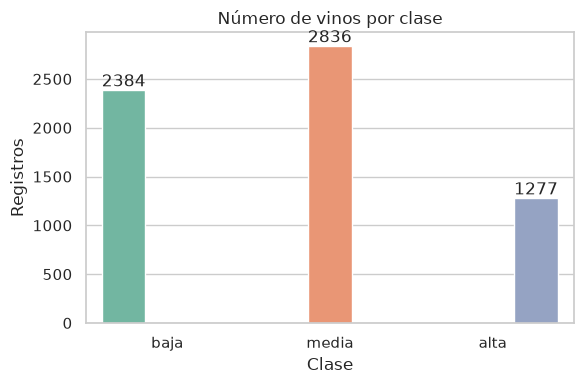

In [7]:
conteo = eda_df["clase"].value_counts().sort_index()
proporcion = (conteo / conteo.sum() * 100).round(2)
display(pd.DataFrame({"Registros": conteo, "Proporción (%)": proporcion}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda_df, x="clase", hue="clase", legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Número de vinos por clase")
ax.set_xlabel("Clase")
ax.set_ylabel("Registros")
plt.tight_layout()
plt.show()

#### 2.5 Distribución de las variables predictoras

Histogramas con estimación de densidad (KDE) para observar la forma, la asimetría y la posible multimodalidad de cada variable.

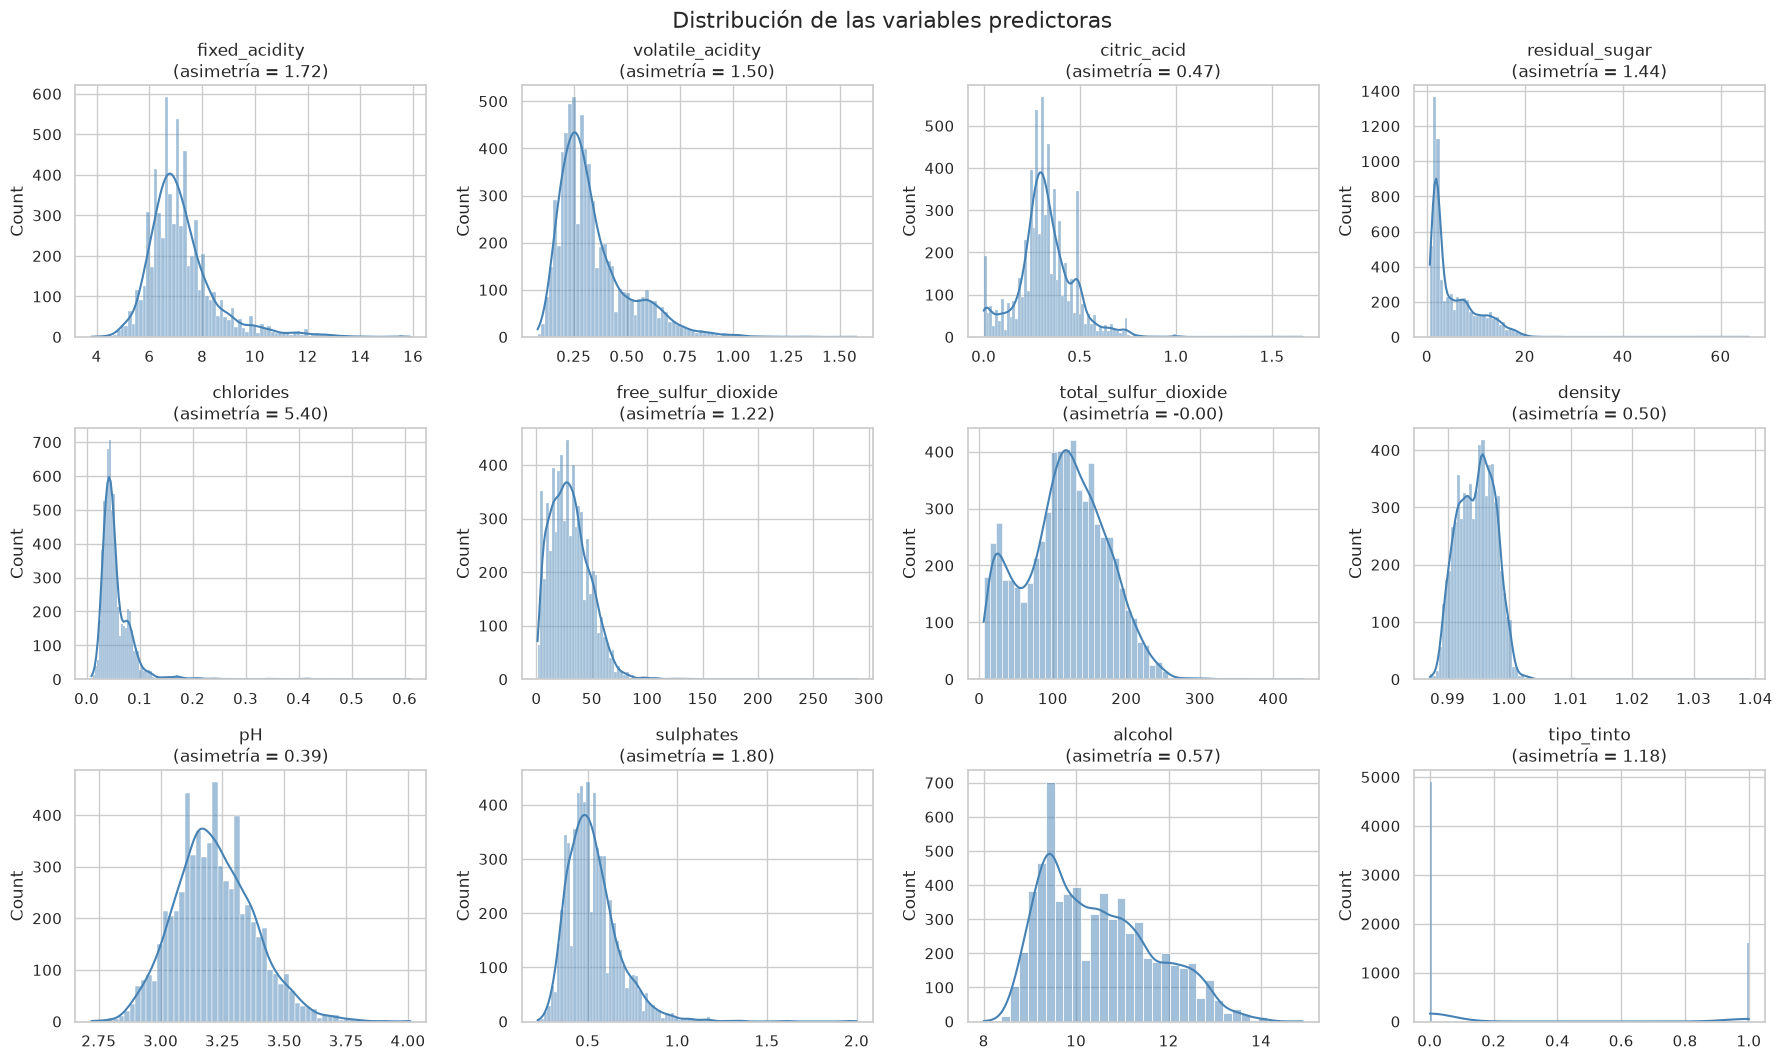

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(wine_df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}\n(asimetría = {wine_df[col].skew():.2f})")
    axes[i].set_xlabel("")
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribución de las variables predictoras", fontsize=16)
plt.tight_layout()
plt.show()

#### 2.6 Distribución por clase y valores atípicos

Los diagramas de caja por clase permiten ver qué variables separan mejor las clases y dónde se concentran los valores atípicos.

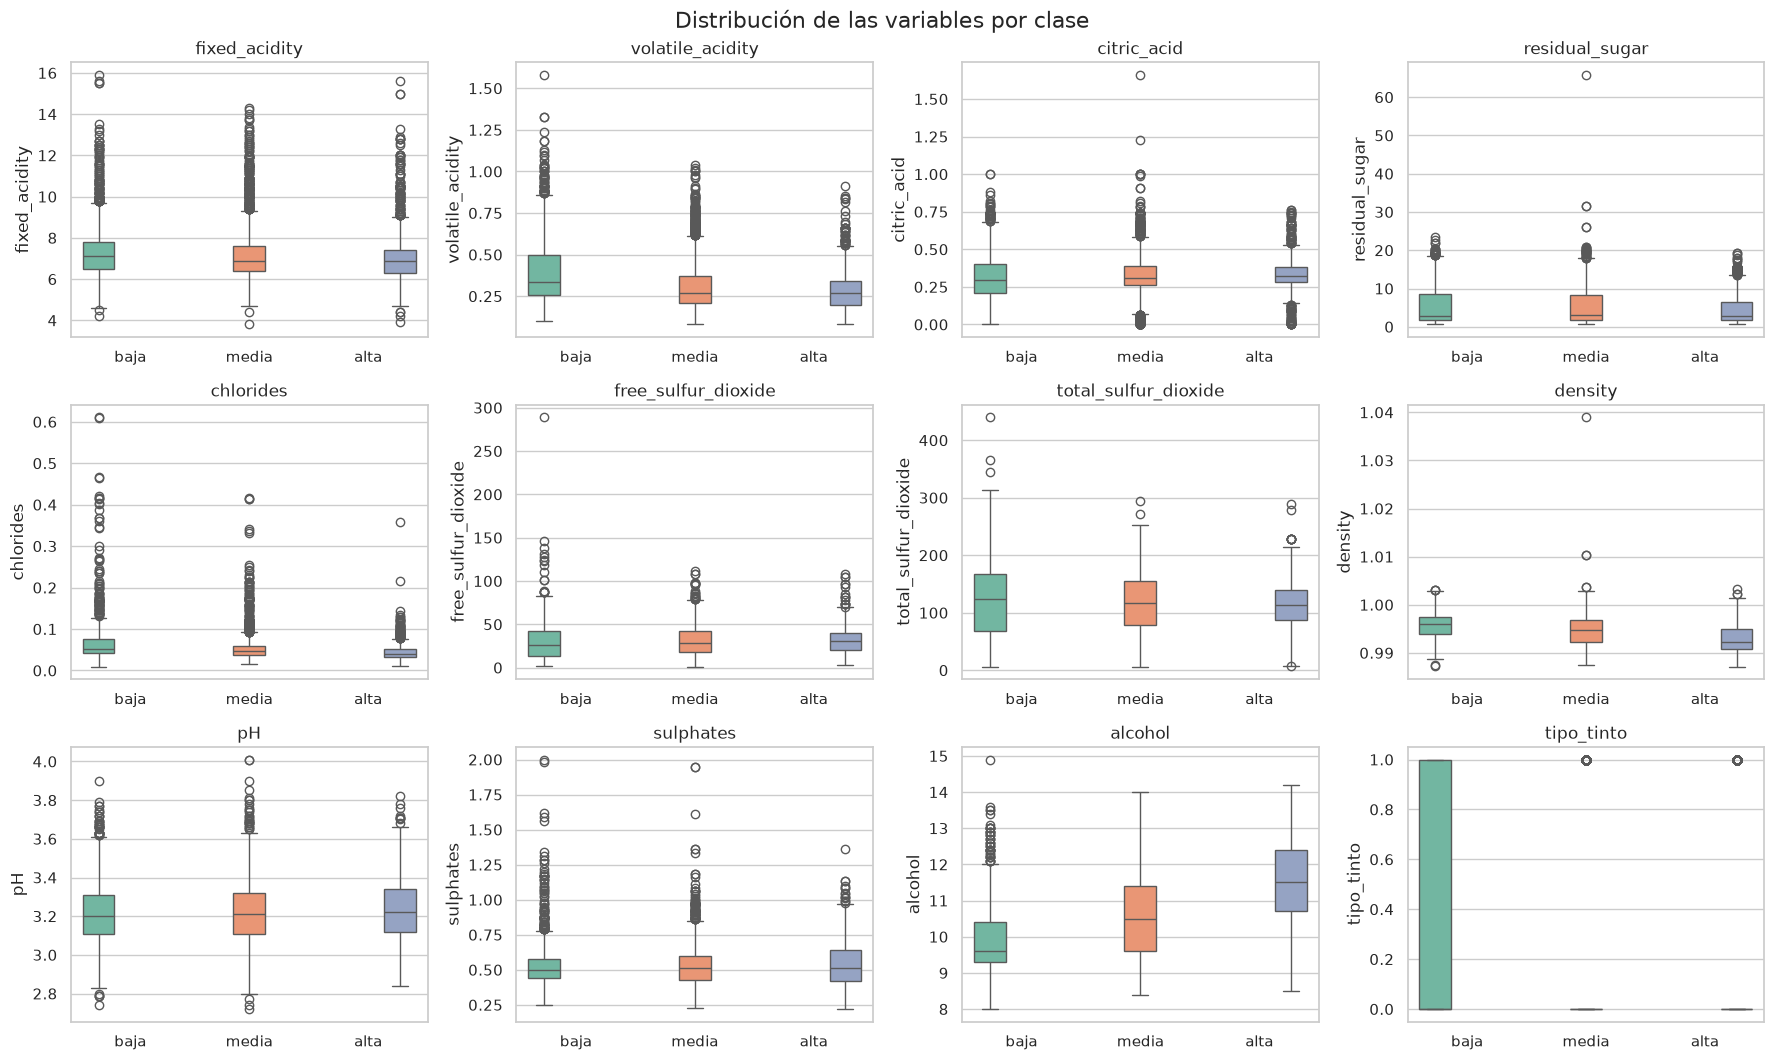

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(data=eda_df, x="clase", y=col, hue="clase", legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribución de las variables por clase", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# Detección de valores atípicos con el criterio del rango intercuartílico (IQR)
q1 = wine_df.quantile(0.25)
q3 = wine_df.quantile(0.75)
iqr = q3 - q1
atipicos = ((wine_df < q1 - 1.5 * iqr) | (wine_df > q3 + 1.5 * iqr)).sum()
display(pd.DataFrame({
    "Atípicos (IQR)": atipicos,
    "% del total": (atipicos / len(wine_df) * 100).round(2)
}).sort_values("Atípicos (IQR)", ascending=False))

,Atípicos (IQR),% del total
tipo_tinto,1599,24.61
citric_acid,509,7.83
volatile_acidity,377,5.80
fixed_acidity,357,5.49
chlorides,286,4.40
sulphates,191,2.94
residual_sugar,118,1.82
pH,73,1.12
free_sulfur_dioxide,62,0.95
total_sulfur_dioxide,10,0.15


#### 2.7 Estadísticas por clase y poder discriminante

Se comparan las medias por clase y se aplica un ANOVA de un factor a cada variable. Un estadístico F alto indica que la variable separa bien las clases.

clase,baja,media,alta
fixed_acidity,7.330,7.177,7.086
volatile_acidity,0.397,0.314,0.289
citric_acid,0.304,0.324,0.335
residual_sugar,5.646,5.550,4.828
chlorides,0.064,0.054,0.045
free_sulfur_dioxide,29.480,31.165,31.055
total_sulfur_dioxide,119.277,115.411,109.891
density,0.996,0.995,0.993
pH,3.215,3.218,3.228
sulphates,0.524,0.533,0.541


,F,p-valor
alcohol,936.92,0.00e+00
density,391.71,2.43e-161
volatile_acidity,260.85,1.08e-109
chlorides,146.71,4.81e-63
tipo_tinto,52.15,3.40e-23
citric_acid,21.31,5.98e-10
fixed_acidity,17.01,4.27e-08
residual_sugar,13.62,1.25e-06
total_sulfur_dioxide,11.59,9.44e-06
free_sulfur_dioxide,6.55,1.44e-03


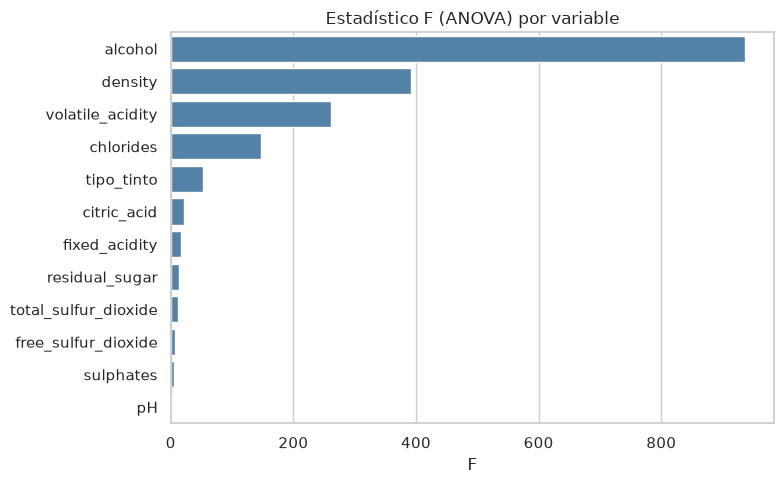

In [11]:
display(eda_df.groupby("clase", observed=True)[features].mean().T.round(3))

anova = pd.DataFrame(
    [stats.f_oneway(*[eda_df.loc[eda_df["target"] == k, col] for k in range(len(CLASES))]) for col in features],
    index=features, columns=["F", "p-valor"]
).sort_values("F", ascending=False)
display(anova.style.format({"F": "{:.2f}", "p-valor": "{:.2e}"}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=anova["F"], y=anova.index, color="steelblue", ax=ax)
ax.set_title("Estadístico F (ANOVA) por variable")
ax.set_xlabel("F")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

#### 2.8 Relaciones entre variables: matriz de correlación

Se usa la correlación de Pearson (relaciones lineales) sobre las 13 variables predictoras.

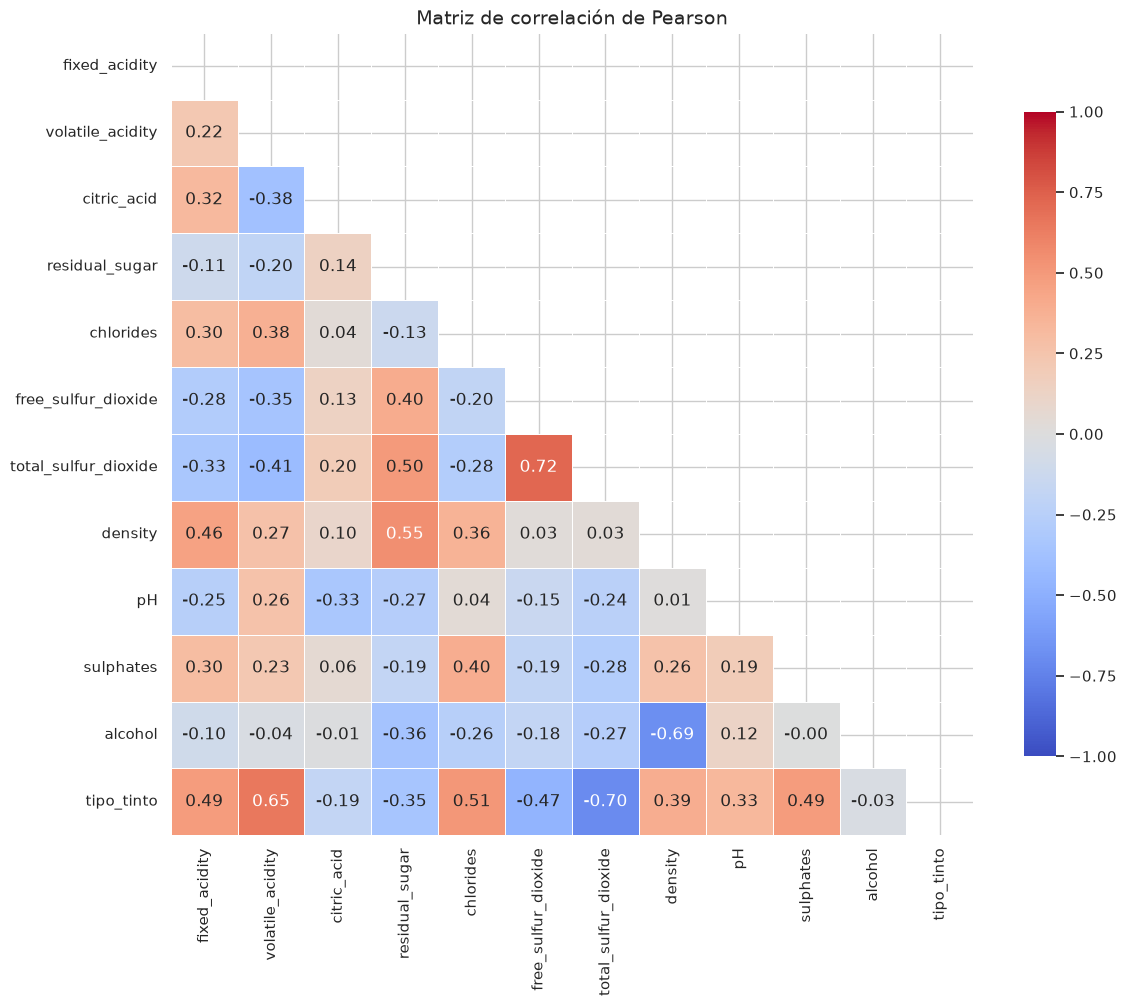

In [12]:
corr = wine_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación de Pearson", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Pares de variables con mayor correlación absoluta
pares = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
             .stack()
             .rename("correlación")
             .to_frame())
pares["|correlación|"] = pares["correlación"].abs()
display(pares.sort_values("|correlación|", ascending=False).head(10).round(3))

,,correlación,|correlación|
free_sulfur_dioxide,total_sulfur_dioxide,0.721,0.721
total_sulfur_dioxide,tipo_tinto,-0.700,0.700
density,alcohol,-0.687,0.687
volatile_acidity,tipo_tinto,0.653,0.653
residual_sugar,density,0.553,0.553
chlorides,tipo_tinto,0.513,0.513
residual_sugar,total_sulfur_dioxide,0.495,0.495
sulphates,tipo_tinto,0.487,0.487
fixed_acidity,tipo_tinto,0.487,0.487
free_sulfur_dioxide,tipo_tinto,-0.472,0.472


#### 2.9 Hallazgos del análisis exploratorio

* **Calidad de los datos:** 6,497 registros, 0 nulos y 1,177 duplicados (18 %).
* **Clases:** baja 36.7 %, media 43.7 % y alta 19.7 %.
* **Escalas:** muy distintas. Por ejemplo, `total_sulfur_dioxide` tiene media ≈ 116 y `density` ≈ 0.995.
* **Sesgo positivo:** fuerte en `chlorides` (5.40), `sulphates` (1.80), `fixed_acidity` (1.72) y `volatile_acidity` (1.50).
* **Atípicos:** hasta 7.8 % por variable (`citric_acid`), muchos más que en el dataset anterior.
* **Correlaciones:** `free_sulfur_dioxide`–`total_sulfur_dioxide` (0.72), `total_sulfur_dioxide`–`tipo_tinto` (−0.70) y `density`–`alcohol` (−0.69).
* **Implicación para el modelo:** los diagramas de caja muestran mucho traslape entre clases. Eso anticipa un baseline lineal modesto.